In [1]:
from pathlib import Path

import pandas as pd
from plots import plot_f

In [2]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    print(
        f"Found versions for {path.name}: {[v.name for v in versions]}. Returning {versions[-1]}"
    )
    return path.name, versions[-1]


def earliest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    print(
        f"Found versions for {path.name}: {[v.name for v in versions]}. Returning {versions[-1]}"
    )
    return path.name, versions[0]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))]
        for k, v in splits
        if k != "unknown"
    }

In [3]:
training_data_route = Path("../../tmp/foundation/experiment_b")

target_schedules = pd.read_csv(training_data_route / "nts_activities_2024.csv")
target_attributes = pd.read_csv(training_data_route / "nts_attributes_2024.csv")

training_attributes = {
    "uk": pd.read_csv(training_data_route / "uk_attributes.csv"),
    # "uk+aus": pd.read_csv(training_data_route / "uk+aus_attributes.csv"),
    # "western": pd.read_csv(training_data_route / "west_attributes.csv"),
    "world": pd.read_csv(training_data_route / "world_attributes.csv"),
}

training_schedules = {
    "uk": pd.read_csv(training_data_route / "uk_activities.csv"),
    # "uk+aus": pd.read_csv(training_data_route / "uk+aus_activities.csv"),
    # "western": pd.read_csv(training_data_route / "west_activities.csv"),
    "world": pd.read_csv(training_data_route / "world_activities.csv"),
}

/tmp/ipykernel_2205499/313738967.py:10: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  "world": pd.read_csv(training_data_route / "world_attributes.csv"),


In [4]:
counter = {}
# load each and get counts per source
counter["baseline"] = target_attributes.source.value_counts()
for name, data in training_attributes.items():
    print(data.source.unique())
    counter[name] = data.source.value_counts()
df = pd.DataFrame(counter)


order = ["ktdb", "ltds", "vista", "qhts", "nhts", "nts"]
df = df.loc[order].fillna(0)
totals = df.sum()
totals_row = pd.DataFrame([totals], index=["Total"])
df = pd.concat([df, totals_row])
print(df.to_latex(float_format="{:.0f}".format))

['ltds' 'nts']
['ktdb' 'ltds' 'vista' 'qhts' 'nhts' 'nts']
\begin{tabular}{lrrr}
\toprule
 & baseline & uk & world \\
\midrule
ktdb & 0 & 0 & 90798 \\
ltds & 0 & 25812 & 25812 \\
vista & 0 & 0 & 11014 \\
qhts & 0 & 0 & 23271 \\
nhts & 0 & 0 & 8623 \\
nts & 69826 & 69826 & 69826 \\
Total & 69826 & 95638 & 229344 \\
\bottomrule
\end{tabular}



In [5]:
def distance_table(batch_path, suffix=""):
    df = pd.read_csv(batch_path / "domains" / "distances.csv").set_index(
        "domain"
    )
    order = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]
    print(df.loc[order].to_latex(float_format="{:.3f}".format))
    return df.loc[order]


df = distance_table(Path("../../logs/foundations2/B/eval"), suffix="")

df

\begin{tabular}{lrrrrrrr}
\toprule
 & world_2023_concat & world_2023_ntf & world_2023_concat_inj & world_2023_inputs & world_2023_inv_all & world_2023_concat_labels & world_2023_all \\
domain &  &  &  &  &  &  &  \\
\midrule
participations & 0.063 & 0.066 & 0.093 & 0.069 & 0.067 & 0.061 & 0.090 \\
transitions & 0.007 & 0.006 & 0.007 & 0.007 & 0.007 & 0.006 & 0.006 \\
timing & 0.033 & 0.031 & 0.042 & 0.034 & 0.034 & 0.033 & 0.039 \\
feasibility & 0.013 & 0.014 & 0.025 & 0.006 & 0.014 & 0.017 & 0.017 \\
creativity & 0.211 & 0.217 & 0.224 & 0.210 & 0.206 & 0.211 & 0.210 \\
\bottomrule
\end{tabular}



,world_2023_concat,world_2023_ntf,world_2023_concat_inj,world_2023_inputs,world_2023_inv_all,world_2023_concat_labels,world_2023_all
domain,,,,,,,
participations,0.063138,0.066144,0.092613,0.068964,0.066683,0.061006,0.089840
transitions,0.006898,0.006332,0.007003,0.006988,0.006692,0.006191,0.006110
timing,0.032733,0.030823,0.041706,0.034182,0.034111,0.032555,0.038503
feasibility,0.013494,0.014109,0.025387,0.005573,0.013538,0.016961,0.017246
creativity,0.211166,0.217023,0.224259,0.209954,0.206239,0.210728,0.210249


In [6]:
df_alt = distance_table(Path("../../logs/foundations2/B/eval"), suffix="")
diff = 100 * (df - df_alt) / df_alt
order = ["participations", "transitions", "timing", "feasibility", "creativity"]
print(diff.loc[order].to_latex(float_format="{:.1f}\%".format))
diff

\begin{tabular}{lrrrrrrr}
\toprule
 & world_2023_concat & world_2023_ntf & world_2023_concat_inj & world_2023_inputs & world_2023_inv_all & world_2023_concat_labels & world_2023_all \\
domain &  &  &  &  &  &  &  \\
\midrule
participations & 0.063 & 0.066 & 0.093 & 0.069 & 0.067 & 0.061 & 0.090 \\
transitions & 0.007 & 0.006 & 0.007 & 0.007 & 0.007 & 0.006 & 0.006 \\
timing & 0.033 & 0.031 & 0.042 & 0.034 & 0.034 & 0.033 & 0.039 \\
feasibility & 0.013 & 0.014 & 0.025 & 0.006 & 0.014 & 0.017 & 0.017 \\
creativity & 0.211 & 0.217 & 0.224 & 0.210 & 0.206 & 0.211 & 0.210 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrrr}
\toprule
 & world_2023_concat & world_2023_ntf & world_2023_concat_inj & world_2023_inputs & world_2023_inv_all & world_2023_concat_labels & world_2023_all \\
domain &  &  &  &  &  &  &  \\
\midrule
participations & 0.0\% & 0.0\% & 0.0\% & 0.0\% & 0.0\% & 0.0\% & 0.0\% \\
transitions & 0.0\% & 0.0\% & 0.0\% & 0.0\% & 0.0\% & 0.0\% & 0.0\% \\
timing & 0.0\% & 0.0\% & 0

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2205499/435248688.py:4: SyntaxWarning: invalid escape sequence '\%'
  print(diff.loc[order].to_latex(float_format="{:.1f}\%".format))


,world_2023_concat,world_2023_ntf,world_2023_concat_inj,world_2023_inputs,world_2023_inv_all,world_2023_concat_labels,world_2023_all
domain,,,,,,,
participations,0.0,0.0,0.0,0.0,0.0,0.0,0.0
transitions,0.0,0.0,0.0,0.0,0.0,0.0,0.0
timing,0.0,0.0,0.0,0.0,0.0,0.0,0.0
feasibility,0.0,0.0,0.0,0.0,0.0,0.0,0.0
creativity,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# _ = plot_b(
#     training_schedules, training_attributes, target_schedules, target_attributes
# )

In [94]:
batch_root = Path("../../logs/foundations2/B")

batch_paths = {
    "no_aus_2023_actvae": batch_root / "no_aus_2023_cvae",
    "no_aus_2023_table_encoder": batch_root / "no_aus_2023_table_encoder",
    "no_aus_2023_no_forcing": batch_root / "no_aus_2023_no_forcing",
    "no_aus_2023_film_labels": batch_root / "no_aus_2023_film_labels",
    "no_aus_2023_decoder_outputs_injection": batch_root
    / "no_aus_2023_decoder_outputs_injection",
    "no_aus_2023_film_all_labels": batch_root / "no_aus_2023_film_all_labels",
    "no_aus_2023_add_labels": batch_root / "no_aus_2023_add_labels",
    "no_aus_2023_all": batch_root / "no_aus_2023_all",
}

# find data
data_root = Path("../../../foundata/output/nts_2023")
target_schedules = pd.read_csv(data_root / "activities.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(data_root / "binned_attributes.csv")

schedules = {
    n: pd.read_csv(latest(p)[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(latest(p)[1], default=target_attributes)
    for n, p in batch_paths.items()
}
print(schedules.keys())
print(attributes.keys())

Found versions for no_aus_2023_cvae: ['version_0', 'version_1']. Returning ../../logs/foundations2/B/no_aus_2023_cvae/version_1
Found versions for no_aus_2023_table_encoder: ['version_0']. Returning ../../logs/foundations2/B/no_aus_2023_table_encoder/version_0
Found versions for no_aus_2023_no_forcing: ['version_0']. Returning ../../logs/foundations2/B/no_aus_2023_no_forcing/version_0
Found versions for no_aus_2023_film_labels: ['version_0', 'version_1']. Returning ../../logs/foundations2/B/no_aus_2023_film_labels/version_1
Found versions for no_aus_2023_decoder_outputs_injection: ['version_0']. Returning ../../logs/foundations2/B/no_aus_2023_decoder_outputs_injection/version_0
Found versions for no_aus_2023_film_all_labels: ['version_0']. Returning ../../logs/foundations2/B/no_aus_2023_film_all_labels/version_0
Found versions for no_aus_2023_add_labels: ['version_0']. Returning ../../logs/foundations2/B/no_aus_2023_add_labels/version_0
Found versions for no_aus_2023_all: ['version_0',

In [95]:
# attributes["world_2023_concat"].employment.value_counts()

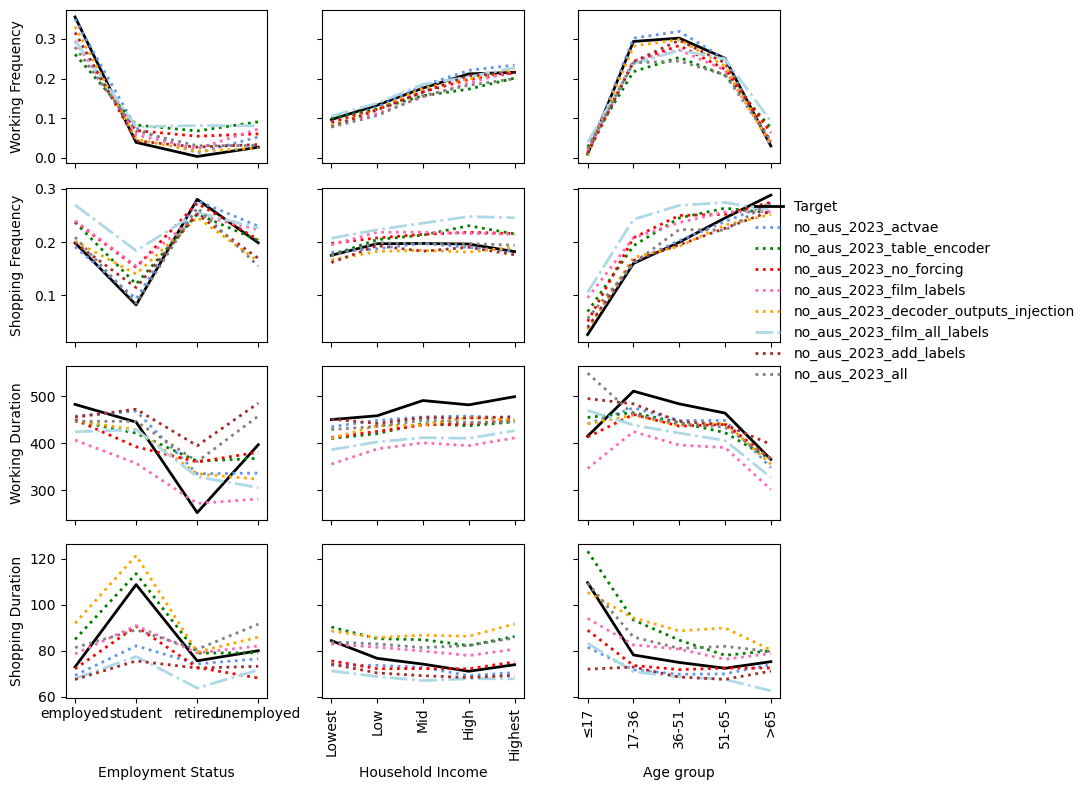

In [96]:
_ = plot_f(schedules, attributes, target_schedules, target_attributes)

In [ ]:
western_data_root = Path("../../../foundata/output/western_2023")
western_target_schedules = pd.read_csv(western_data_root / "activities.csv")
western_target_attributes = pd.read_csv(
    western_data_root / "binned_attributes.csv"
)

splits = split_on(
    western_target_schedules, western_target_attributes, by="source"
)

/tmp/ipykernel_2205499/579790170.py:3: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  western_target_attributes = pd.read_csv(


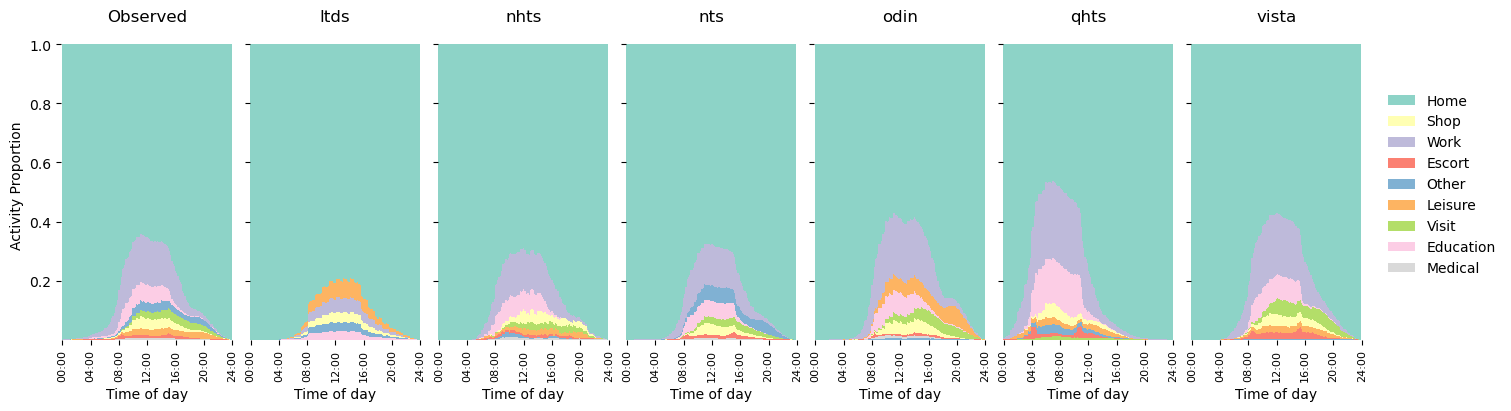

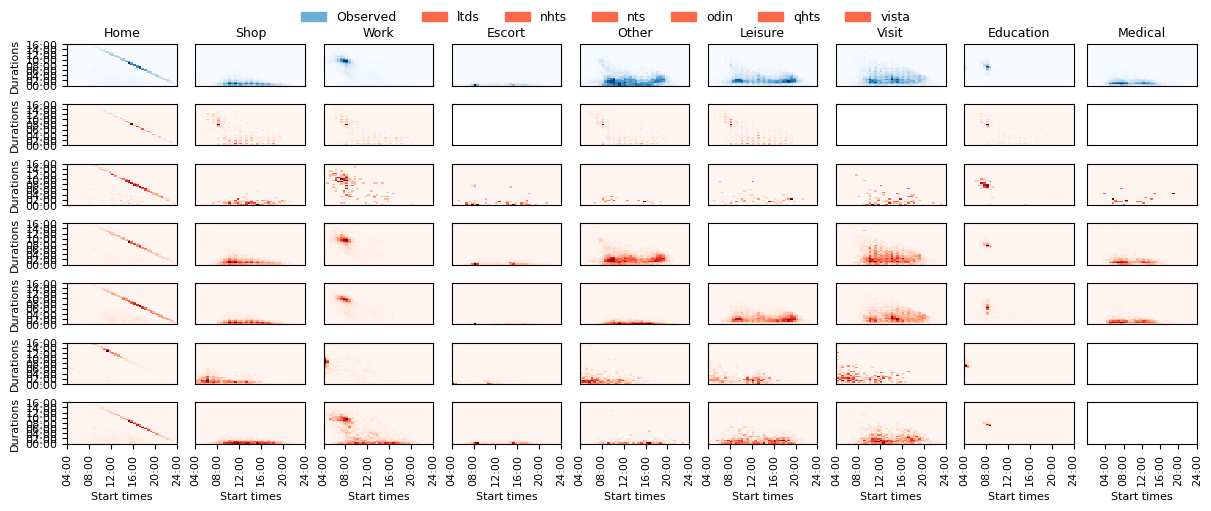

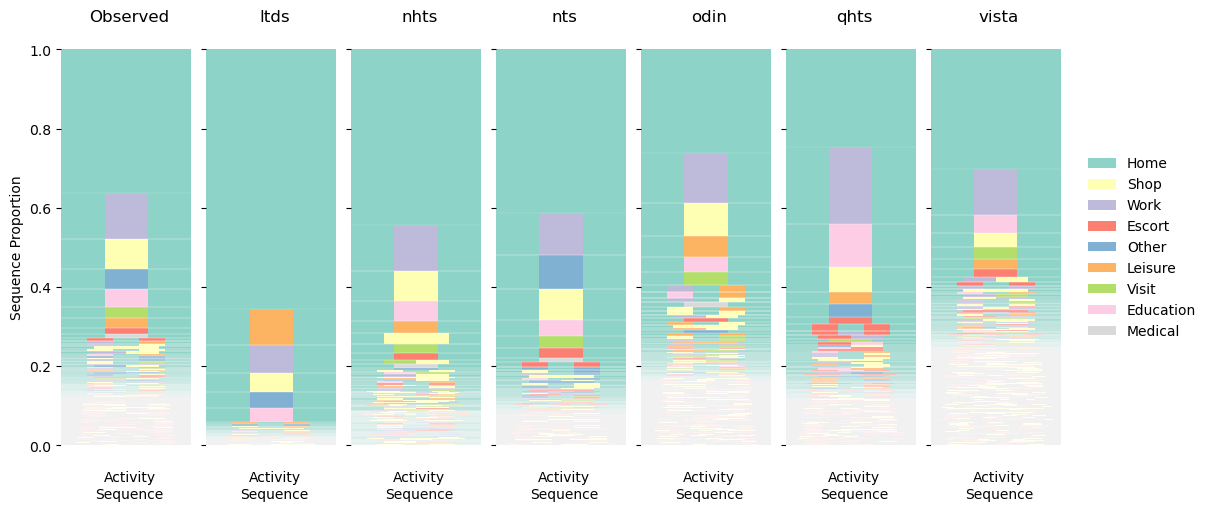

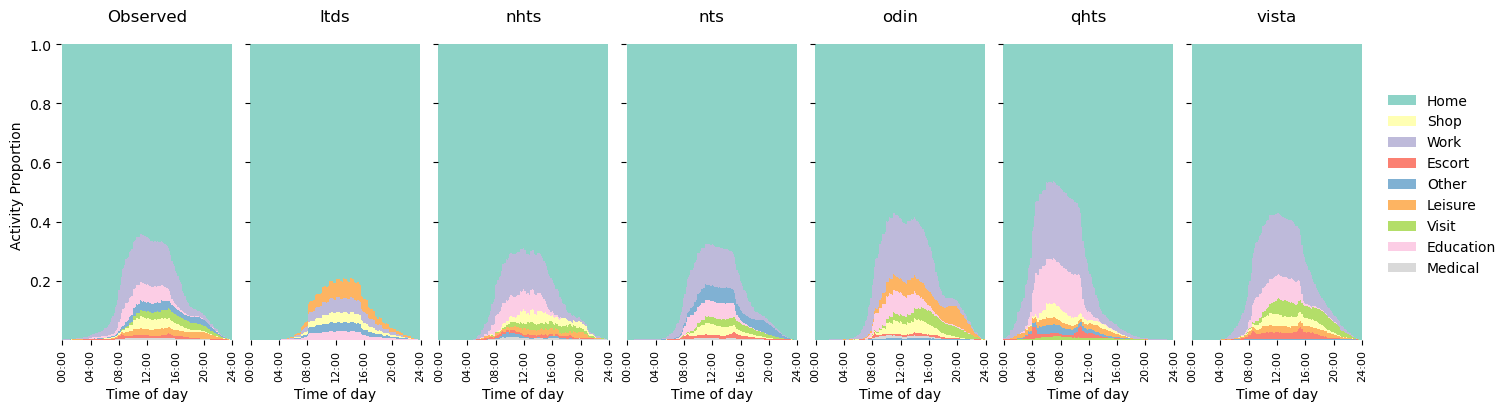

In [63]:
from acteval.describe.frequency import frequency_plots
from acteval.describe.times import joint_time_distributions_plot
from acteval.describe.transitions import sequence_prob_plot

joint_time_distributions_plot(observed=western_target_schedules, ys=splits)
sequence_prob_plot(observed=western_target_schedules, ys=splits)
frequency_plots(observed=western_target_schedules, ys=splits)

In [17]:
# ! pip install statsmodels

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols


def trips_table(schedules, attributes):
    trips = attributes.copy()
    counts = schedules.groupby("pid").size() - 1
    trips = pd.merge(trips, counts.rename("trips"), on="pid")
    return trips


def anova_concept_shift(
    schedules,
    attributes,
    categorical_cols,
    outcome_col="trips",
    source_col="source",
    interaction_flag_threshold=0.01,
):
    """
    For each label in categorical_cols, test on the real (combined, multi-
    source) data:

        outcome ~ C(label) + C(source) + C(label):C(source)

    The interaction term (label:source) is the key diagnostic: a large,
    significant interaction eta_sq means the label's effect on the outcome
    genuinely differs by source (concept shift) -- not just that label
    or source distributions differ marginally (covariate shift).

    Args:
        schedules: combined schedules df across all sources.
        attributes: combined attributes df across all sources, with a
            `source_col` column already present.
        categorical_cols: label columns to test.
        outcome_col: name of the outcome column produced by trips_table.
        source_col: name of the column identifying source/country.
        interaction_flag_threshold: eta_sq above which a label is flagged
            as showing concept shift.
    """
    df_combined = trips_table(schedules, attributes)

    results = []

    for cat in categorical_cols:
        print("\n=========================================")
        print(f"2-Way ANOVA (concept-shift check) for: {cat}")
        print("=========================================")

        formula = f"{outcome_col} ~ C({cat}) + C({source_col}) + C({cat}):C({source_col})"

        model = ols(formula, data=df_combined).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        anova_table["eta_sq"] = (
            anova_table["sum_sq"] / anova_table["sum_sq"].sum()
        )

        print(anova_table[["df", "F", "PR(>F)", "eta_sq"]])

        interaction_row_name = f"C({cat}):C({source_col})"
        if interaction_row_name in anova_table.index:
            interaction_eta_sq = anova_table.loc[interaction_row_name, "eta_sq"]
            interaction_p = anova_table.loc[interaction_row_name, "PR(>F)"]

            flagged = interaction_eta_sq > interaction_flag_threshold
            if flagged:
                print(
                    f"  [CONCEPT SHIFT FLAG] {cat}: interaction eta_sq = "
                    f"{interaction_eta_sq:.4f} (p={interaction_p:.4g}) -- "
                    f"effect of {cat} on {outcome_col} appears to differ by {source_col}."
                )

            results.append(
                {
                    "label": cat,
                    "interaction_eta_sq": interaction_eta_sq,
                    "interaction_p": interaction_p,
                    "flagged": flagged,
                }
            )

    summary_df = pd.DataFrame(results).sort_values(
        "interaction_eta_sq", ascending=False
    )
    print("\n=========================================")
    print("Summary: interaction (label x source) effect sizes")
    print("=========================================")
    print(summary_df)

    return summary_df


# --- usage ---

categorical_cols = [
    "vehicles",
    "age",
    "day",
    "employment",
    "hh_income",
    "hh_zone",
    "access_egress_distance",
    "sex",
]

summary = anova_concept_shift(
    target_schedules,
    target_attributes,
    categorical_cols,
    outcome_col="trips",
    source_col="source",
)


2-Way ANOVA (concept-shift check) for: vehicles


/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 48
  warnings.warn('covariance of constraints does not have full '


                             df             F  PR(>F)        eta_sq
C(vehicles)                12.0  8.687861e+02     0.0  5.515239e-02
C(source)                   5.0  8.595843e-07     1.0  2.273677e-11
C(vehicles):C(source)      60.0  1.136694e+02     0.0  3.607988e-02
Residual               171784.0           NaN     NaN  9.087677e-01
  [CONCEPT SHIFT FLAG] vehicles: interaction eta_sq = 0.0361 (p=0) -- effect of vehicles on trips appears to differ by source.

2-Way ANOVA (concept-shift check) for: age
                        df            F         PR(>F)    eta_sq
C(age)                 4.0   630.834085   0.000000e+00  0.013556
C(source)              5.0  2175.368046   0.000000e+00  0.058435
C(age):C(source)      20.0    46.285903  8.699423e-183  0.004973
Residual          171810.0          NaN            NaN  0.923035

2-Way ANOVA (concept-shift check) for: day


/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 28
  warnings.warn('covariance of constraints does not have full '


                        df            F         PR(>F)    eta_sq
C(day)                 6.0   283.739495  1.286372e-243  0.008983
C(source)              5.0  3052.801086   0.000000e+00  0.080539
C(day):C(source)      30.0    25.205539  2.396340e-130  0.003990
Residual          171800.0          NaN            NaN  0.906488

2-Way ANOVA (concept-shift check) for: employment


...

/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 25, but rank is 23
  warnings.warn('covariance of constraints does not have full '


                              df            F         PR(>F)    eta_sq
C(hh_income)                 5.0   695.099071   0.000000e+00  0.018881
C(source)                    5.0  1589.599411   0.000000e+00  0.043179
C(hh_income):C(source)      25.0    33.604943  4.179518e-148  0.004564
Residual                171806.0          NaN            NaN  0.933375

2-Way ANOVA (concept-shift check) for: hh_zone
                            df            F         PR(>F)    eta_sq
C(hh_zone)                 2.0   281.531032  8.560992e-123  0.002995
C(source)                  5.0  2767.997583   0.000000e+00  0.073619
C(hh_zone):C(source)      10.0   176.790875   0.000000e+00  0.009404
Residual              171823.0          NaN            NaN  0.913981

2-Way ANOVA (concept-shift check) for: access_egress_distance


/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 25, but rank is 1
  warnings.warn('covariance of constraints does not have full '


                                           df            F    PR(>F)    eta_sq
C(access_egress_distance)                 5.0  6017.186309  0.000000  0.149003
C(source)                                 5.0     0.057075  0.811181  0.000001
C(access_egress_distance):C(source)      25.0     0.185170  0.666968  0.000023
Residual                             171824.0          NaN       NaN  0.850973

2-Way ANOVA (concept-shift check) for: sex
                        df            F        PR(>F)    eta_sq
C(sex)                 2.0    91.073055  1.401818e-21  0.001007
C(source)              5.0  1764.625997  0.000000e+00  0.048770
C(sex):C(source)      10.0     8.051552  1.027789e-08  0.000445
Residual          171826.0          NaN           NaN  0.949778

Summary: interaction (label x source) effect sizes
                    label  interaction_eta_sq  interaction_p  flagged
3              employment            0.043124   0.000000e+00     True
0                vehicles            0.036080   0

/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols


def anova_concept_shift(
    schedules,
    attributes,
    categorical_cols,
    outcome_col="trips",
    source_col="source",
):
    """
    For each label in categorical_cols, run:
        outcome ~ C(label) + C(source) + C(label):C(source)

    Returns a per-label summary with both the main effect and interaction
    effect sizes, so ranking can be done on raw interaction size or on
    the interaction-to-main-effect ratio.
    """
    df_combined = trips_table(schedules, attributes)
    results = []

    for cat in categorical_cols:
        formula = f"{outcome_col} ~ C({cat}) + C({source_col}) + C({cat}):C({source_col})"
        model = ols(formula, data=df_combined).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        anova_table["eta_sq"] = (
            anova_table["sum_sq"] / anova_table["sum_sq"].sum()
        )

        main_row = f"C({cat})"
        interaction_row = f"C({cat}):C({source_col})"

        results.append(
            {
                "label": cat,
                "main_eta_sq": anova_table.loc[main_row, "eta_sq"],
                "main_p": anova_table.loc[main_row, "PR(>F)"],
                "interaction_eta_sq": anova_table.loc[
                    interaction_row, "eta_sq"
                ],
                "interaction_p": anova_table.loc[interaction_row, "PR(>F)"],
            }
        )

    return pd.DataFrame(results)


def rank_by_interaction_strength(
    summary_df, method="ratio", min_main_eta_sq=1e-4
):
    """
    Rank labels by the strength of their source interaction effect.

    Args:
        summary_df: output of anova_concept_shift.
        method:
            "raw"   - rank by interaction_eta_sq alone. Simple, but a label
                      that barely matters at all (tiny main effect) can
                      still show a nonzero interaction just from noise, so
                      this can be misleading for weak labels.
            "ratio" - rank by interaction_eta_sq / main_eta_sq. Answers
                      "of the variance this label explains at all, how
                      much of that is source-dependent?" More informative
                      for labels that matter (high main effect) but behave
                      inconsistently across source. Guarded against
                      division blowups on near-zero main effects via
                      `min_main_eta_sq`.
        min_main_eta_sq: labels with main_eta_sq below this are excluded
            from "ratio" ranking (their ratio is unstable/uninformative)
            and flagged separately.

    Returns:
        DataFrame sorted by the chosen ranking, with an added `rank`
        column and (for "ratio") an `excluded_low_main_effect` flag.
    """
    df = summary_df.copy()

    if method == "raw":
        df = df.sort_values("interaction_eta_sq", ascending=False).reset_index(
            drop=True
        )
        df["rank"] = df.index + 1
        return df

    elif method == "ratio":
        df["excluded_low_main_effect"] = df["main_eta_sq"] < min_main_eta_sq
        df["interaction_ratio"] = df["interaction_eta_sq"] / df["main_eta_sq"]

        ranked = df[~df["excluded_low_main_effect"]].sort_values(
            "interaction_ratio", ascending=False
        )
        excluded = df[df["excluded_low_main_effect"]].sort_values(
            "interaction_eta_sq", ascending=False
        )

        df = pd.concat([ranked, excluded], ignore_index=True)
        df["rank"] = range(1, len(df) + 1)
        return df

    else:
        raise ValueError(f"Unknown method: {method}")


# --- usage ---

categorical_cols = [
    "vehicles",
    "age",
    "day",
    "employment",
    "hh_income",
    "hh_zone",
    "access_egress_distance",
    "sex",
]

summary = anova_concept_shift(
    target_schedules,
    target_attributes,
    categorical_cols,
    outcome_col="trips",
    source_col="source",
)

ranked = rank_by_interaction_strength(summary, method="ratio")
print(
    ranked[
        [
            "rank",
            "label",
            "main_eta_sq",
            "interaction_eta_sq",
            "interaction_ratio",
            "excluded_low_main_effect",
        ]
    ]
)

/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 6
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 60, but rank is 48
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints i

   rank                   label  main_eta_sq  interaction_eta_sq  \
0     1              employment     0.009814            0.043124   
1     2                 hh_zone     0.002995            0.009404   
2     3                vehicles     0.055152            0.036080   
3     4                     day     0.008983            0.003990   
4     5                     sex     0.001007            0.000445   
5     6                     age     0.013556            0.004973   
6     7               hh_income     0.018881            0.004564   
7     8  access_egress_distance     0.149003            0.000023   

   interaction_ratio  excluded_low_main_effect  
0           4.393942                     False  
1           3.139812                     False  
2           0.654185                     False  
3           0.444167                     False  
4           0.442038                     False  
5           0.366863                     False  
6           0.241728                     Fal

/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/home/fred/miniforge3/envs/caveat/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 6
  warnings.warn('covariance of constraints does not have full '
